# Simple Linear Regession Model: Predicting sunday newspaper circulation based on weekly newspaper circulation

## Import Dataset

In [1]:
import pandas as pd
df_news = pd.read_csv("NewspaperData.csv")
df_news

,Newspaper,daily,sunday
0,Baltimore Sun,391.952,488.506
1,Boston Globe,516.981,798.298
2,Boston Herald,355.628,235.084
3,Charlotte Observer,238.555,299.451
4,Chicago Sun Times,537.780,559.093
5,Chicago Tribune,733.775,1133.249
6,Cincinnati Enquirer,198.832,348.744
7,Denver Post,252.624,417.779
8,Des Moines Register,206.204,344.522
9,Hartford Courant,231.177,323.084


In [3]:
df_news.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Newspaper  34 non-null     str    
 1   daily      34 non-null     float64
 2   sunday     34 non-null     float64
dtypes: float64(2), str(1)
memory usage: 1.5 KB


### Correlation

In [5]:
df_news.corr(numeric_only=True)

,daily,sunday
daily,1.000000,0.958154
sunday,0.958154,1.000000


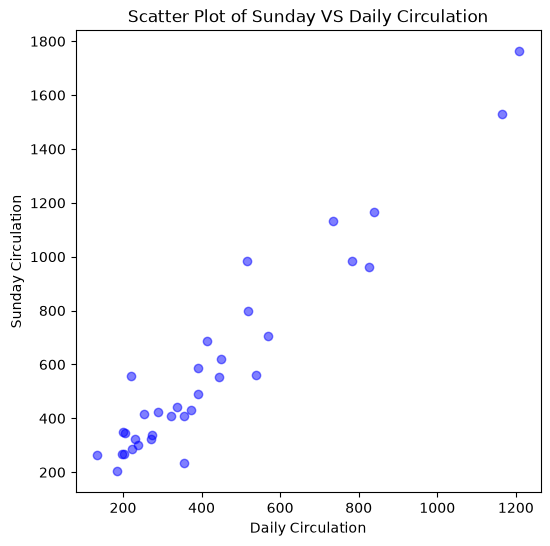

In [6]:
import matplotlib.pyplot as plt

# Extracting dauly and sunday circulatiion data
daily_data = df_news.daily
sunday_data = df_news.sunday

# Plotting Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(daily_data,sunday_data,alpha=0.5,color='blue')
plt.title('Scatter Plot of Sunday VS Daily Circulation')
plt.xlabel('Daily Circulation')
plt.ylabel('Sunday Circulation')
plt.show()

### Fitting a Linear Regression Model

In [7]:
import statsmodels.formula.api as sfm

model = sfm.ols("sunday~daily", data =df_news).fit() # ordinary least square method for calc co-efficient

In [8]:
# Regressionequation has built successfully

In [9]:
model.params

Intercept    13.835630
daily         1.339715
dtype: float64

In [10]:
# t-value and p-value
print(f"model t-value:\n{model.tvalues}\n--------------------------\nmodel p-value:\n{model.pvalues}")

model t-value:
Intercept     0.386427
daily        18.934840
dtype: float64
--------------------------
model p-value:
Intercept    7.017382e-01
daily        6.016802e-19
dtype: float64


#### To sumarize if p-value of any feature(variable) is lessthan 0.05, that variable is important, and suggest not drop from dataset

In [11]:
# Coefficients
model.params

Intercept    13.835630
daily         1.339715
dtype: float64

In [14]:
# To predict from 500 daily circulations
(1.339715*500)+13.835630

683.69313

In [15]:
# R squared values
(model.rsquared,model.rsquared_adj)

(np.float64(0.9180596895873295), np.float64(0.9154990548869336))

### Predict for new data Points

In [16]:
new_data =pd.Series([200,300,500])
new_data

0    200
1    300
2    500
dtype: int64

In [18]:
data_pred=pd.DataFrame(new_data,columns=['daily'])
data_pred

,daily
0,200
1,300
2,500


In [19]:
model.predict(data_pred)

0    281.778581
1    415.750057
2    683.693009
dtype: float64

In [20]:
model.summary()  # From referance / research purpose

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 sunday   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     358.5
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           6.02e-19
Time:                        16:47:41   Log-Likelihood:                -206.85
No. Observations:                  34   AIC:                             417.7
Df Residuals:                      32   BIC:                             420.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.8356     35.804      0.386      0.702     -59.095      86.766
daily          1.3397      0.071     18.935      0.000       1.196       1.484
==============================================================================
Omnibus:                        3.297   Durbin-Watson:                   2.059
Prob(Omnibus):                  0.192   Jarque-Bera (JB):                1.990
Skew:                           0.396   Prob(JB):                        0.370
Kurtosis:                       3.882   Cond. No.                         965.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""